DATA VIZ

In [39]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

BASE = "./chest_xray"
classes = ["NORMAL", "PNEUMONIA"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

random.seed(42)
all_files = {}
for cls in classes:
    path = os.path.join(BASE, cls) #/chest_xray/NORMAL.jpg
    #files = [f for f in os.listdir(path) if os.path.splitext(f)[1].lower() in IMAGE_EXTS]
    files = []
    for f in os.listdir(path):
        ext = os.path.splitext(f)[1].lower()

        if ext in IMAGE_EXTS:
            files.append(f)
    random.shuffle(files)
    all_files[cls] = files

splits_data = {"train": {}, "val": {}, "test": {}}
for cls, files in all_files.items():
    n = len(files)
    n_train = int(n * 0.8)
    n_val   = int(n * 0.1)
    splits_data["train"][cls] = files[:n_train]
    splits_data["val"][cls]   = files[n_train:n_train + n_val]
    splits_data["test"][cls]  = files[n_train + n_val:]


In [42]:
def summarize_splits(splits_data):
    print("\nDataset Summary")

    total = 0

    for split_name, split in splits_data.items():
        print(f"\n{split_name.upper()}:")

        split_total = 0

        for cls, files in split.items():
            count = len(files)
            split_total += count
            print(f"  {cls}: {count}")

        total += split_total
        print(f"  ➜ Total: {split_total}")

    print(f"\nOverall total images: {total}")


summarize_splits(splits_data)


Dataset Summary

TRAIN:
  NORMAL: 1266
  PNEUMONIA: 3418
  ➜ Total: 4684

VAL:
  NORMAL: 158
  PNEUMONIA: 427
  ➜ Total: 585

TEST:
  NORMAL: 159
  PNEUMONIA: 428
  ➜ Total: 587

Overall total images: 5856


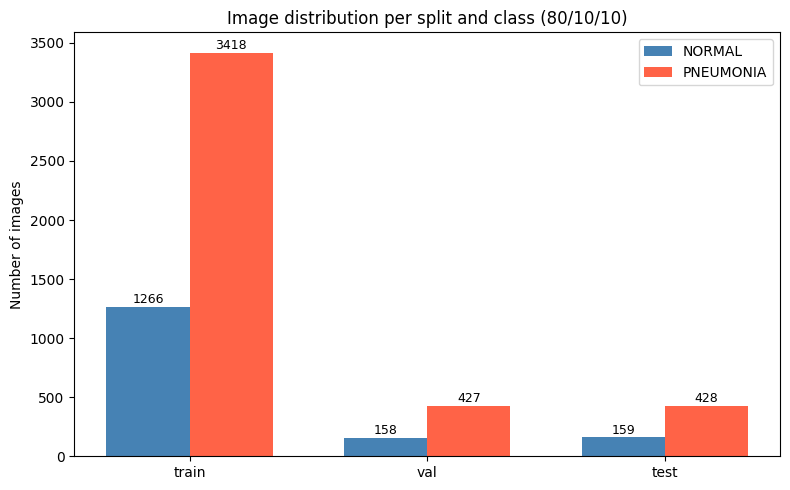

In [43]:
splits = ["train", "val", "test"]
counts = {split: {cls: len(splits_data[split][cls]) for cls in classes} for split in splits}

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, [counts[s]["NORMAL"]    for s in splits], width, label="NORMAL",    color="steelblue")
bars2 = ax.bar(x + width/2, [counts[s]["PNEUMONIA"] for s in splits], width, label="PNEUMONIA", color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel("Number of images")
ax.set_title("Image distribution per split and class (80/10/10)")
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

Show some lungs :)

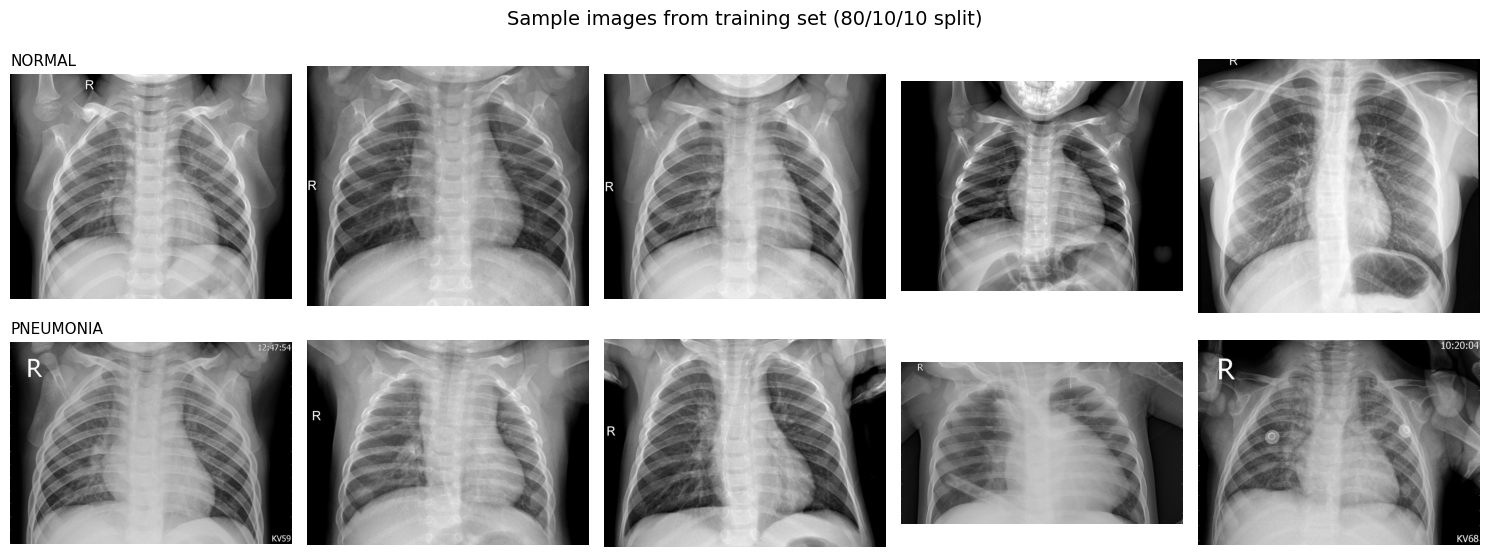

In [44]:
# Show sample images from the training split
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample images from training set (80/10/10 split)", fontsize=14)

for row, cls in enumerate(classes): # 0 = NORMAL, 1 = PNEUMONIA
    base_path = os.path.join(BASE, cls)
    files = splits_data["train"][cls][:5]
    for col, fname in enumerate(files): # 0 = img1, 1 = img2, 2 = img3 etc.
        img = mpimg.imread(os.path.join(base_path, fname))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(cls, fontsize=11, loc="left")

plt.tight_layout()
plt.show()

Show class distribution

In [49]:
# Total count per class across train/val/test
class_totals = {}

for cls in classes:
    total = 0

    for split in splits:
        total += counts[split][cls]

    class_totals[cls] = total
class_totals

{'NORMAL': 1583, 'PNEUMONIA': 4273}

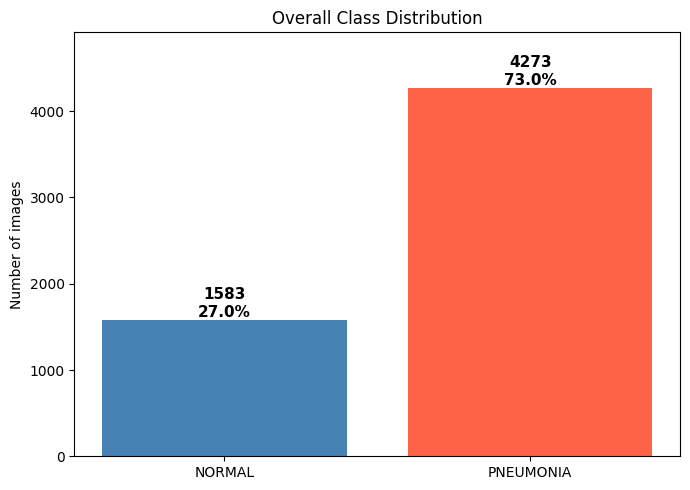

Class distribution:
NORMAL: 1583 images (27.0%)
PNEUMONIA: 4273 images (73.0%)


In [52]:
total_images = sum(class_totals.values())

class_names = ["NORMAL", "PNEUMONIA"]
values = [class_totals[key] for key in class_names]
percentages = [(value / total_images) * 100 for value in values]

colors = ["steelblue", "tomato"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(class_names, values, color=colors)

ax.set_title("Overall Class Distribution")
ax.set_ylabel("Number of images")
ax.set_ylim(0, max(values) * 1.15)

# Add count and percentage labels above bars
for bar, count, pct in zip(bars, values, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("Class distribution:")
for name, count, pct in zip(class_names, values, percentages):
    print(f"{name}: {count} images ({pct:.1f}%)")

There's a clear class imbalance here, we need to handle this

**Preprocessing**

Keep images to the 224x224 standard

In [55]:
import os
import torch
from PIL import Image, ImageOps
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt

BASE = "./chest_xray"
classes = ["NORMAL", "PNEUMONIA"]
BATCH_SIZE = 32
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}
IMG_SIZE = 224
print(f"Using fixed resize target: {IMG_SIZE}x{IMG_SIZE}px")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class PadToSquare: #Example 1000x500 turns to 1000 x 1000 px, prevents stretching before resizing
    def __init__(self, fill=0):
        self.fill = fill

    def __call__(self, image):
        width, height = image.size

        if width == height:
            return image

        max_side = max(width, height)

        padding_left = (max_side - width) // 2
        padding_right = max_side - width - padding_left
        padding_top = (max_side - height) // 2
        padding_bottom = max_side - height - padding_top

        padding = (
            padding_left,
            padding_top,
            padding_right,
            padding_bottom
        )

        return ImageOps.expand(image, padding, fill=self.fill)

Using fixed resize target: 224x224px
Using device: cuda


In [56]:
train_transform = transforms.Compose([ #Input example: Blue x-ray 1200 x 800 px
    transforms.Grayscale(num_output_channels=3), # gray-scaled x-ray 1200 x 800
    PadToSquare(fill=0), # 1200x1200 (black bars added)
    transforms.Resize((IMG_SIZE, IMG_SIZE)), #resized to 224x224

    # Light augmentation only
    transforms.RandomAffine(
        degrees=7, # rotate between -7 and - 7 degrees
        translate=(0.03, 0.03), # Moves the img horizontally or vertically up to 3% of the image height
        scale=(0.97, 1.03) #zoom between 97% and 103%
    ),

    transforms.ToTensor(),

    # ImageNet normalization if using pretrained CNNs later.
    # Also works fine with 3-channel grayscale images.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    PadToSquare(fill=0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [24]:
class ChestXraySplitDataset(torch.utils.data.Dataset):
    def __init__(self, base_dir, split_files, classes, transform=None):
        self.base_dir = base_dir
        self.split_files = split_files
        self.classes = classes
        self.transform = transform

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(classes)
        }

        self.samples = []

        for class_name in classes:
            class_dir = os.path.join(base_dir, class_name)

            for filename in split_files[class_name]:
                image_path = os.path.join(class_dir, filename)
                label = self.class_to_idx[class_name]
                self.samples.append((image_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [25]:
train_dataset = ChestXraySplitDataset(
    base_dir=BASE,
    split_files=splits_data["train"],
    classes=classes,
    transform=train_transform
)

val_dataset = ChestXraySplitDataset(
    base_dir=BASE,
    split_files=splits_data["val"],
    classes=classes,
    transform=eval_transform
)

test_dataset = ChestXraySplitDataset(
    base_dir=BASE,
    split_files=splits_data["test"],
    classes=classes,
    transform=eval_transform
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Train images: 4684
Validation images: 585
Test images: 587


In [26]:
train_labels = [label for _, label in train_dataset.samples]

class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

print("Training class counts:", class_counts)
print("Class weights:", class_weights)

Training class counts: [1266 3418]
Class weights: [0.00078989 0.00029257]


In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

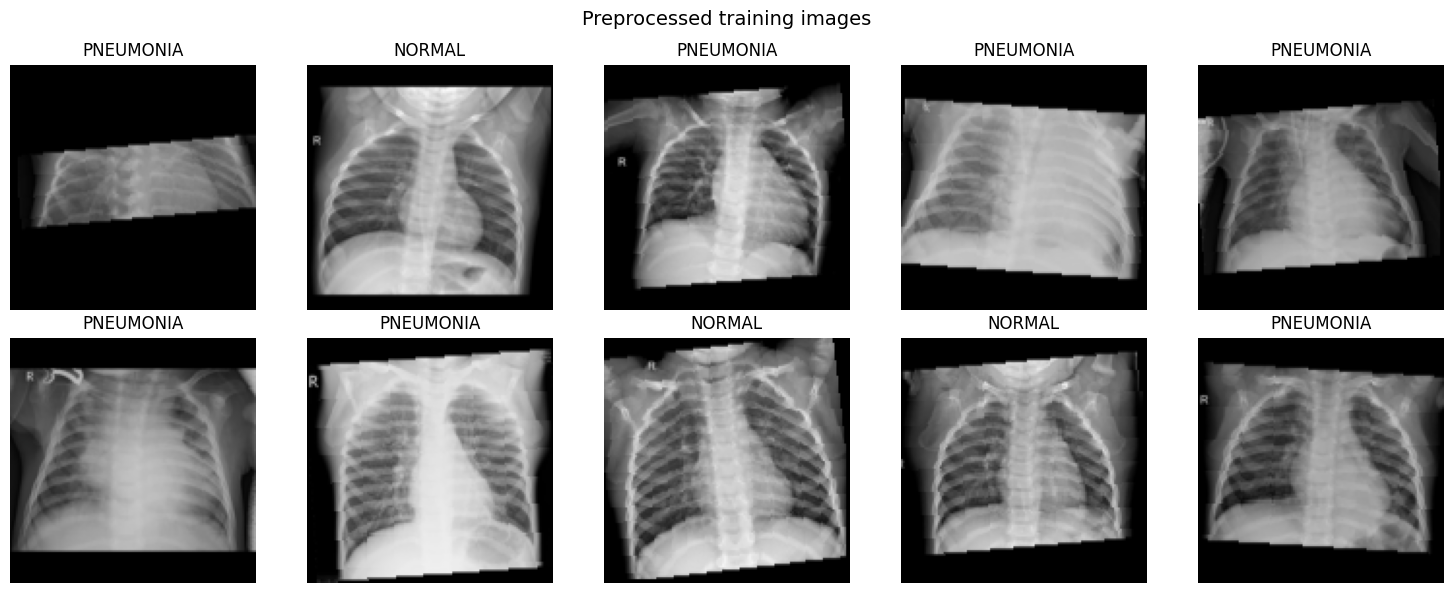

In [28]:
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = tensor.cpu() * std + mean
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Preprocessed training images", fontsize=14)

for i, ax in enumerate(axes.flat):
    image = denormalize_image(images[i])
    label = classes[labels[i].item()]

    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()